In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 단순 회귀 모델

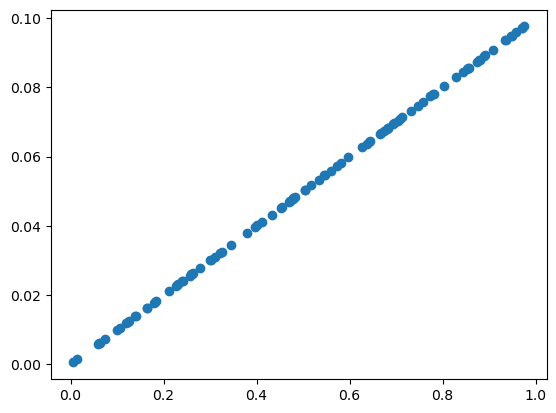

In [2]:
X = np.random.rand(100)
y = 0.2*X*0.5
plt.scatter(X,y)

In [3]:
def plt_prediction(pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X, y, color='blue', label='Actual')
    plt.scatter(X, pred, color='orange', label='Prediction')
    plt.legend()
    plt.show()

In [ ]:
# 경사하강법 y=wX+b 의 가중치와 편향의 초기값 설정 , w결정
W = np.random.uniform(-1,1) #X의 가중치
b = np.random.uniform(-1,1) #b 편향
learning_rate = 0.5 #임의 값 #학습율

epoch 0, W: 0.0955, Error: 0.0011


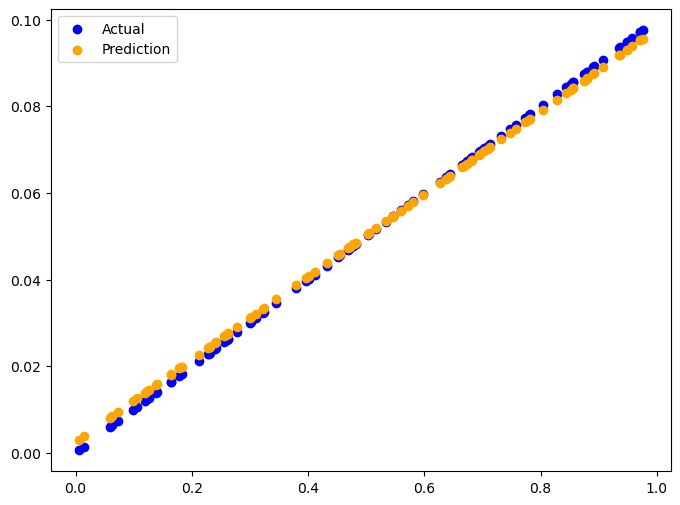

In [ ]:
for epoch in range(100):
  y_pred = W * X + b
  error = np.abs(y_pred - y).mean() #평균절대오차 MAE
  if error < 0.001 :
    break
  #경사하강법에 의한 W,b의 조정
  W_descent = learning_rate * ( (y_pred - y)*X).mean()
  b_descent = learning_rate * ( (y_pred - y)).mean()
  W = W - W_descent
  b = b - b_descent
  
  #10epoch마다 시각화
  if epoch%10 == 0 :
    print(f'epoch {epoch}, W: {W:.4f}, Error: {error:.4f}')
    y_pred = W*X + b
    plt_prediction(y_pred, y)

# LinearRegression

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [9]:
from sklearn.datasets import fetch_california_housing

In [13]:
house = fetch_california_housing()
house_df = pd.DataFrame(house.data, columns=house.feature_names)
house_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
#target
house_df['Price'] = house.target
house_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

In [15]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [20]:
# 데이터 분할
X = house_df.drop('Price', axis=1).values
y = house_df['Price'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, random_state=42)

In [21]:
# LinearRegression 모델
house_lr = LinearRegression()
house_lr.fit(X_train, y_train)
y_pred = house_lr.predict(X_test)
y_pred[10]

np.float64(0.9444186089981201)

In [23]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(0.7284008391515456), 0.5305677824766759)

In [24]:
r2_score(y_test, y_pred)

0.5957702326061659

In [26]:
house_lr, house_lr.coef_

(LinearRegression(),
 array([ 4.45822565e-01,  9.68186799e-03, -1.22095112e-01,  7.78599557e-01,
        -7.75740400e-07, -3.37002667e-03, -4.18536747e-01, -4.33687976e-01]))

In [27]:
house_lr.coef_, house_lr.intercept_

(array([ 4.45822565e-01,  9.68186799e-03, -1.22095112e-01,  7.78599557e-01,
        -7.75740400e-07, -3.37002667e-03, -4.18536747e-01, -4.33687976e-01]),
 np.float64(-37.05624133152509))

In [28]:
pd.Series(data = np.round(house_lr.coef_,1),
          index=house_df.drop('Price', axis=1).columns).sort_values(ascending=False)

AveBedrms     0.8
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

# 다항회귀모델
- 피처 엔지니어링, 전처리
- 다항회귀, 규제

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [30]:
model_poly = Pipeline( [('poly', PolynomialFeatures(degree=2, include_bias=False)),
           ('linear', LinearRegression())])
model_poly.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [31]:
poly_pred = model_poly.predict(X_test)
mean_squared_error(y_test, poly_pred)

0.4549723374747758

In [32]:
r2_score(y_test, poly_pred)

0.6533650021311979

In [33]:
# ── 1. 2차 / 3차 다항회귀 성능 비교 ──────────────────────────────

degrees = [1, 2, 3]
results = {}

for d in degrees:
    if d == 1:
        model = LinearRegression()
    else:
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=d, include_bias=False)),
            ('linear', LinearRegression())
        ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    results[f'{d}차'] = {'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f"[{d}차 다항회귀]  RMSE: {rmse:.4f}  |  R²: {r2:.4f}")

results_df = pd.DataFrame(results).T
print()
print(results_df)

[1차 다항회귀]  RMSE: 0.7284  |  R²: 0.5958
[2차 다항회귀]  RMSE: 0.6745  |  R²: 0.6534
[3차 다항회귀]  RMSE: 2.0102  |  R²: -2.0788

         MSE      RMSE        R²
1차  0.530568  0.728401  0.595770
2차  0.454972  0.674516  0.653365
3차  4.041098  2.010248 -2.078838


In [34]:
# ── 2. 결과가 비슷하거나 과적합이 보일 경우 → 규제(Regularization) 적용 ──

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

# 2차 다항 피처 생성 (규제 모델에 공통 사용)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# 스케일링 (Ridge/Lasso는 스케일에 민감)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled  = scaler.transform(X_test_poly)

reg_models = {
    'Ridge (L2)'   : Ridge(alpha=1.0),
    'Lasso (L1)'   : Lasso(alpha=0.001),
    'ElasticNet'   : ElasticNet(alpha=0.001, l1_ratio=0.5)
}

print("=== 규제 모델 비교 (2차 다항 피처 기반) ===")
reg_results = {}

for name, model in reg_models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    reg_results[name] = {'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f"[{name}]  RMSE: {rmse:.4f}  |  R²: {r2:.4f}")

reg_results_df = pd.DataFrame(reg_results).T
print()
print(reg_results_df)

=== 규제 모델 비교 (2차 다항 피처 기반) ===
[Ridge (L2)]  RMSE: 0.6751  |  R²: 0.6528


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.902e+02, tolerance: 1.936e+00
  model = cd_fast.enet_coordinate_descent(


[Lasso (L1)]  RMSE: 0.6906  |  R²: 0.6366
[ElasticNet]  RMSE: 0.6909  |  R²: 0.6363

                 MSE      RMSE        R²
Ridge (L2)  0.455742  0.675087  0.652779
Lasso (L1)  0.476967  0.690628  0.636608
ElasticNet  0.477380  0.690927  0.636293


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.545e+03, tolerance: 1.936e+00
  model = cd_fast.enet_coordinate_descent(


# Ridge 회귀

In [35]:
from sklearn.linear_model import Ridge

# 3. 릿지 회귀
ridge = Ridge(alpha=1.0)  # alpha는 규제 강도
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

print("\n[릿지 회귀]")
print("MSE:", mean_squared_error(y_test, pred_ridge))
print("R2:", r2_score(y_test, pred_ridge))


[릿지 회귀]
MSE: 0.5305052690933699
R2: 0.5958178603951636


# Lasso 회귀

In [36]:
from sklearn.linear_model import Lasso
# 4. 라쏘 회귀

lasso = Lasso(alpha=0.1)  # alpha 값 작으면 규제 약해짐
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

print("\n[라쏘 회귀]")
print("MSE:", mean_squared_error(y_test, pred_lasso))
print("R2:", r2_score(y_test, pred_lasso))


[라쏘 회귀]
MSE: 0.5970512258509185
R2: 0.5451177283676661


# Elastic Net 회귀

In [37]:
# 5. 엘라스틱넷 회귀
model_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5: L1과 L2의 비중 50:50
model_enet.fit(X_train, y_train)
pred_enet = model_enet.predict(X_test)

print("\n[엘라스틱넷 회귀]")
print("MSE:", mean_squared_error(y_test, pred_enet))
print("R2:", r2_score(y_test, pred_enet))


[엘라스틱넷 회귀]
MSE: 0.5571449056777037
R2: 0.5755216146456115
